# TP3 — Introduction to Graph Machine Learning (Neo4j + GDS)

**Goal:** build a graph from Twitch streams, compute Node2Vec embeddings using Neo4j Graph Data Science (GDS), and analyze similarity between streams.

**Tools:** Docker (Neo4j 5), Neo4j Browser, Neo4j Python Driver, GDS plugin.


Cette cellule vérifie que toutes les librairies Python nécessaires au TP sont bien installées.


In [41]:
!pip install neo4j

## 1. Environment setup (Docker + Neo4j)

we run Neo4j inside Docker to have a clean and reproducible environment.
Ports:
- `7474` → Neo4j Browser (HTTP)
- `7687` → Bolt protocol (Python driver)

Le plugin Graph Data Science (GDS) permet d’appliquer des algorithmes de machine learning
sur des graphes.

In [59]:
from neo4j import GraphDatabase

URI = "bolt://localhost:7687"
AUTH = ("neo4j", "password")

driver = GraphDatabase.driver(URI, auth=AUTH)
driver

Le driver Neo4j permet d’envoyer des requêtes Cypher directement depuis Python.

In [60]:
driver

Let's define a simple encapsulation function to run a cypher query into our neo4j container 

In [61]:
def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return result.to_df()

Cette cellule lance un conteneur Neo4j avec Docker et active le plugin Graph Data Science.


In [62]:
! docker run -d --name neo4j-tp3 \
  -p 7474:7474 -p 7687:7687 \
  -e NEO4J_AUTH=neo4j/password \
  -e NEO4J_PLUGINS='["graph-data-science"]' \
  neo4j:5


docker: Error response from daemon: Conflict. The container name "/neo4j-tp3" is already in use by container "e1383cc5dc1fd7a8c01c5246d20e24083baa0ec482316d597abeb15ec1ec9c55". You have to remove (or rename) that container to be able to reuse that name.

Run 'docker run --help' for more information


Cette cellule lance un conteneur Neo4j avec Docker et active le plugin Graph Data Science.


In [63]:
run_query("SHOW PROCEDURES YIELD name WHERE name STARTS WITH 'gds' RETURN name LIMIT 10;")

,name
0,gds.allShortestPaths.delta.mutate
1,gds.allShortestPaths.delta.mutate.estimate
2,gds.allShortestPaths.delta.stats
3,gds.allShortestPaths.delta.stats.estimate
4,gds.allShortestPaths.delta.stream
5,gds.allShortestPaths.delta.stream.estimate
6,gds.allShortestPaths.delta.write
7,gds.allShortestPaths.delta.write.estimate
8,gds.allShortestPaths.dijkstra.mutate
9,gds.allShortestPaths.dijkstra.mutate.estimate


Cette requête affiche les bases de données disponibles dans le serveur Neo4j.


In [64]:
run_query("""
SHOW DATABASES;
"""
)

,name,type,aliases,access,address,role,writer,requestedStatus,currentStatus,statusMessage,default,home,constituents
0,neo4j,standard,[],read-write,localhost:7687,primary,True,online,online,,True,True,[]
1,system,system,[],read-write,localhost:7687,primary,True,online,online,,False,False,[]


Create a constraint named Stream

On crée une contrainte pour garantir que chaque streamer possède un identifiant unique.


In [65]:
run_query("""
CREATE CONSTRAINT IF NOT EXISTS FOR (s:Stream) REQUIRE s.id IS UNIQUE;
"""
)

""


Cette cellule charge les streamers Twitch depuis un fichier CSV et crée les nœuds correspondants.


In [66]:
run_query("""
LOAD CSV WITH HEADERS FROM "https://bit.ly/3JjgKgZ" AS row
MERGE (s:Stream {id: row.id})
SET s.language = row.language
"""
)

""


Cette cellule charge les streamers Twitch depuis un fichier CSV et crée les nœuds correspondants.


In [67]:
# Load the data 
# 
run_query("""
LOAD CSV WITH HEADERS FROM "https://bit.ly/3S9Uyd8" AS row
CALL{
    WITH row
    MATCH (s:Stream {id:row.source})
    MATCH (t:Stream {id:row.target})
    MERGE (s)-[r:SHARED_AUDIENCE]->(t)
    SET r.weight = toInteger(row.weight)
} IN TRANSACTIONS
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (row) { ... }', position=<SummaryInputPosition line=3, column=1, offset=60>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 60, 'line': 3, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nLOAD CSV WITH HEADERS FROM "https://bit.ly/3S9Uyd8" AS row\nCALL{\n    WITH row\n    MATCH (s:Stream {id:row.source})\n    MATCH (t:Stream {id:row.target})\n    MERGE (s)-[r:SHARED_AUDIENCE]->(t)\n    SET r.weight = toInteger(row.weight)\n} IN TRANSACTIONS\n'


""


In [68]:
run_query("""
CALL gds.graph.project("twitch", "Stream", 
  {SHARED_AUDIENCE: {orientation: "UNDIRECTED", properties:["weight"]}})
"""
)

ClientError: {neo4j_code: Neo.ClientError.Procedure.ProcedureCallFailed} {message: Failed to invoke procedure `gds.graph.project`: Caused by: java.lang.IllegalArgumentException: A graph with name 'twitch' already exists.} {gql_status: 50N42} {gql_status_description: error: general processing exception - unexpected error. Unexpected error has occurred. See debug log for details.}

On vérifie ici que le plugin Graph Data Science est bien installé et accessible dans Neo4j.


In [ ]:
# run query to create node2vec embeddings
run_query("""
CALL gds.beta.node2vec.write('twitch', 
  {embeddingDimension:8, relationshipWeightProperty:'weight',
   inOutFactor:0.5, returnFactor:1, writeProperty:'node2vec'})
"""
)

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.beta.node2vec.write is deprecated. It is replaced by gds.node2vec.write.', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.beta.node2vec.write('twitch', \n  {embeddingDimension:8, relationshipWeightProperty:'weight',\n   inOutFactor:0.5, returnFactor:1, writeProperty:'node2vec'})\n"


,nodeCount,nodePropertiesWritten,preProcessingMillis,computeMillis,writeMillis,configuration,lossPerIteration
0,3721,3721,14,3808,98,"{'negativeSamplingExponent': 0.75, 'negativeSa...",[22275962.489589546]


Cette requête permet de voir les graphes actuellement projetés en mémoire par GDS.


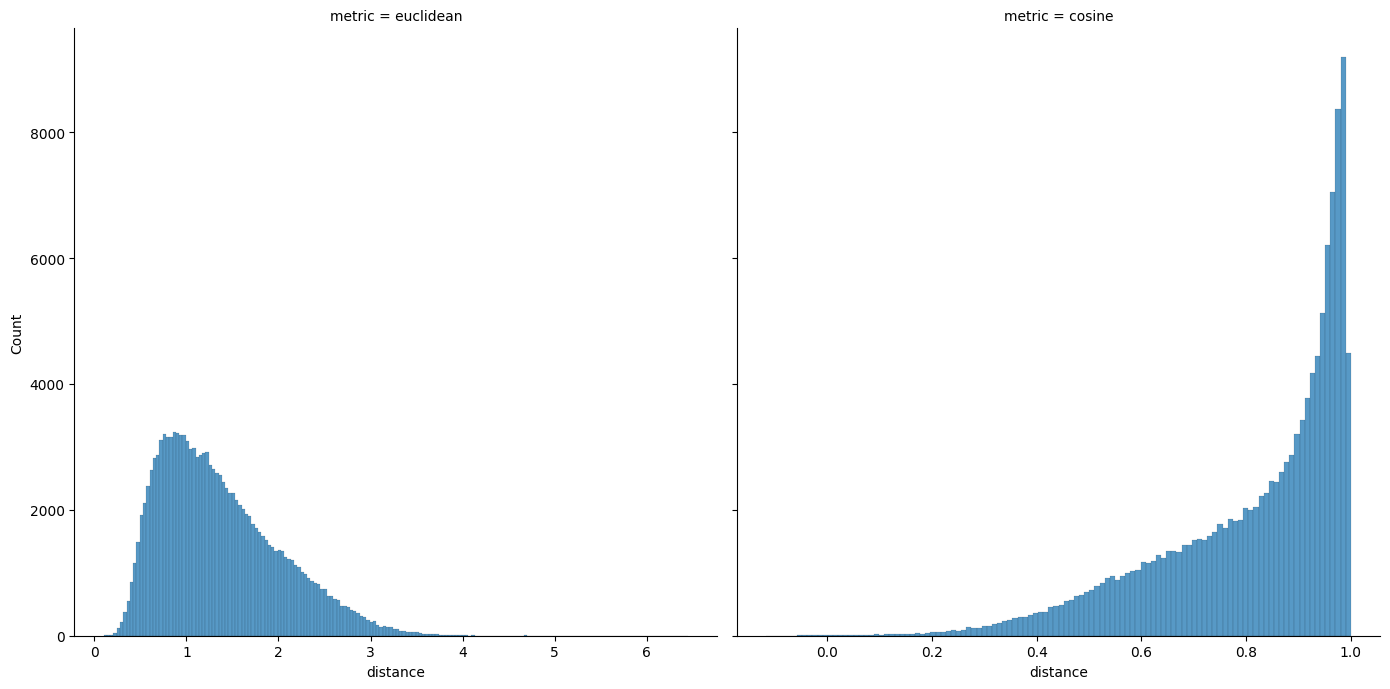

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [16, 9]
import seaborn as sns

df = run_query("""
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
RETURN gds.similarity.euclideanDistance(
   c1.node2vec, c2.node2vec) AS distance, 'euclidean' as metric
UNION
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
RETURN gds.similarity.cosine(
   c1.node2vec, c2.node2vec) AS distance, 'cosine' as metric
"""
)

sns.displot(
    data=df,
    x="distance",
    col="metric",
    common_bins=False,
    facet_kws=dict(sharex=False),
    height=7,
)

Cette cellule applique l’algorithme Node2Vec pour générer des représentations vectorielles des nœuds.


<Axes: xlabel='cosineSimilarity', ylabel='avgDegree'>

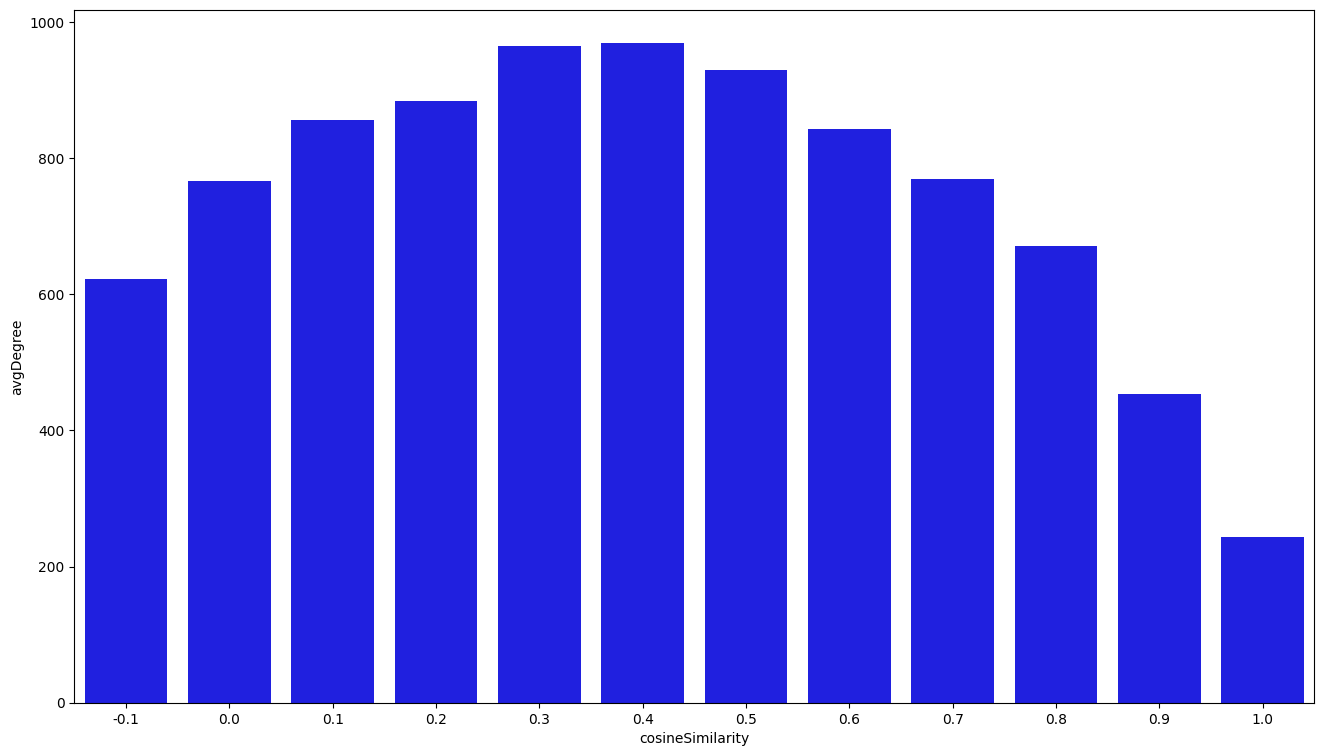

In [ ]:
df = run_query("""
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
WITH c1, c2, gds.similarity.cosine(c1.node2vec, c2.node2vec) AS cosineSimilarity,
     count{ (c1)-[:SHARED_AUDIENCE]-() } AS degree1,
     count{ (c2)-[:SHARED_AUDIENCE]-() } AS degree2
RETURN round(cosineSimilarity,1) AS cosineSimilarity, avg(degree1 + degree2) AS avgDegree
ORDER BY cosineSimilarity
"""
)

sns.barplot(data=df, x="cosineSimilarity", y="avgDegree", color="blue")

On compare les distances entre streamers connectés en utilisant les métriques euclidienne et cosinus.


<Axes: xlabel='cosineSimilarity', ylabel='avgWeight'>

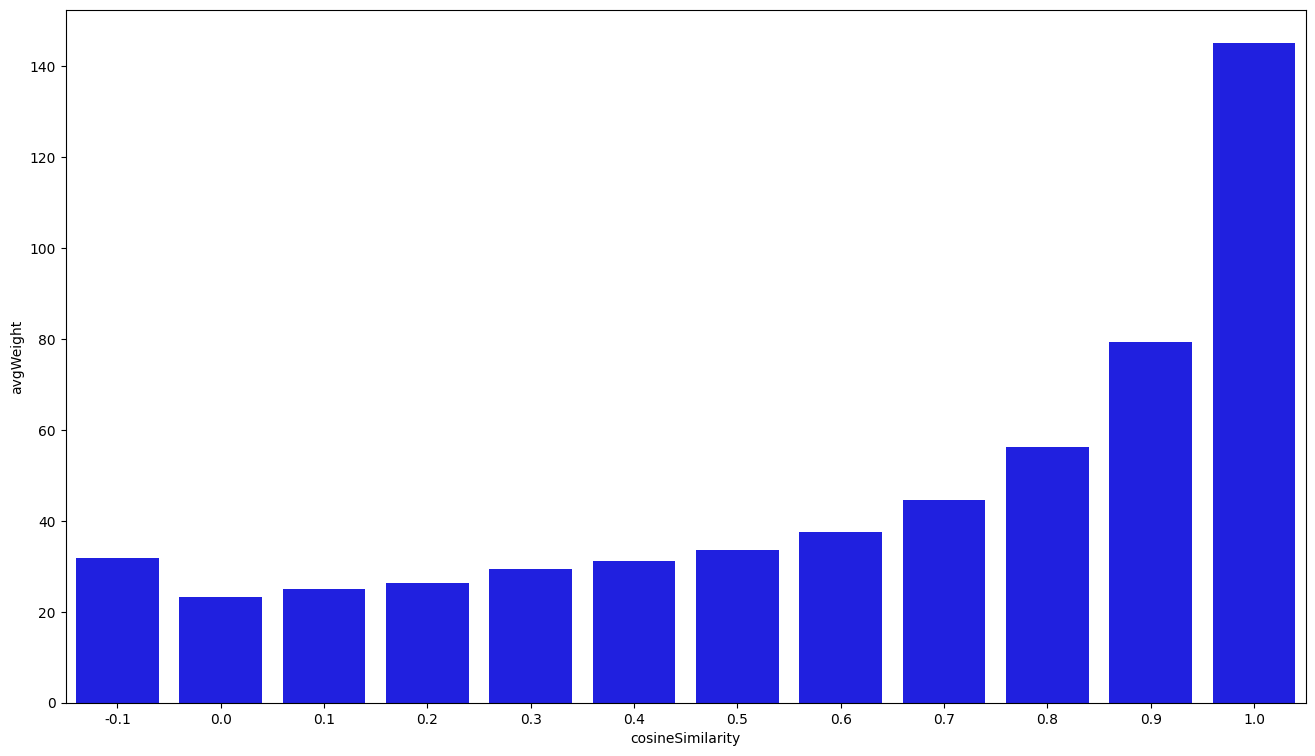

In [ ]:
df = run_query("""
MATCH (c1:Stream)-[r:SHARED_AUDIENCE]->(c2:Stream)
WITH c1, c2, gds.similarity.cosine(c1.node2vec, c2.node2vec) AS cosineSimilarity,
     r.weight AS weight
RETURN round(cosineSimilarity,1) AS cosineSimilarity, avg(weight) AS avgWeight
ORDER BY cosineSimilarity
"""
)

sns.barplot(data=df, x="cosineSimilarity", y="avgWeight", color="blue")

The results show that higher cosine similarity is generally associated with higher average connection strength. This means that streamers who share audiences more intensively are positioned closer together in the graph representation.

In [ ]:
import pandas as pd
data = run_query("""
MATCH (s:Stream)
RETURN s.id AS streamId, s.language AS language, s.node2vec AS embedding
"""
)
data["output"] = pd.factorize(data["language"])[0]

In [ ]:
data.head()

,streamId,language,embedding,output
0,129004176,en,"[1.3515613079071045, -0.26752516627311707, 0.9...",0
1,26490481,en,"[1.6452959775924683, 0.4803822338581085, 0.181...",0
2,213749122,en,"[1.0957926511764526, -0.06436893343925476, 1.5...",0
3,30104304,en,"[1.3086416721343994, 0.6017379760742188, -0.12...",0
4,160504245,en,"[1.2390575408935547, 0.24676164984703064, -0.0...",0


On entraîne un modèle Random Forest afin de prédire la langue d’un streamer à partir de son embedding.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = data["embedding"].to_list()
y = data["output"].to_list()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


On évalue les performances du modèle à l’aide d’un rapport de classification.


In [ ]:
from sklearn.metrics import classification_report

y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       384
           1       0.94      0.91      0.92        54
           2       0.98      0.92      0.95        59
           3       0.82      0.85      0.84        39
           4       0.85      0.90      0.88        52
           5       0.88      0.84      0.86        58
           6       0.95      0.95      0.95        20
           7       0.92      0.96      0.94        25
           8       0.94      0.83      0.88        35
           9       0.95      0.95      0.95        19

    accuracy                           0.90       745
   macro avg       0.91      0.90      0.91       745
weighted avg       0.91      0.90      0.90       745



Cette matrice permet de visualiser les erreurs de classification du modèle de manière plus détaillée.


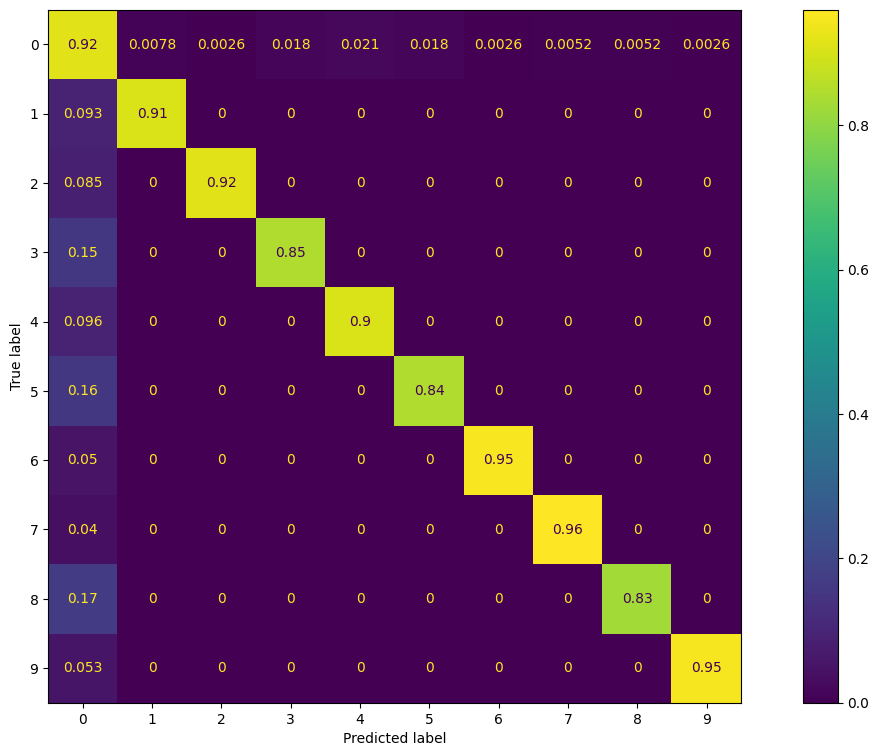

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")